#### Note:

1. Формализовать текущий пайплайн в LangChain (Redis + ChromaDB);
2. Модифицировать его проверками на входе и выходе (необходимо избежать ситуации когда он отвечает абсруд);
3. Модифицировать его циклом на попытку ответа в случае неудачи.
4. Обязательно сделать его человеком при ответе пользователю (возможен routing на human-native answer);
5. Исследуем GPT-oss?

Help docs:

https://yandex.cloud/ru/docs/ai-studio/concepts/generation/models#sdk_1

# Import Libs

In [1]:
import json
from typing import TypedDict, List, Optional
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, END
import numpy as np
import asyncio
from abc import ABC

# Работаем с секретами
from dotenv import load_dotenv
import os

from functools import lru_cache
# Работаем с Redis \ ChromaDB
from UnionChatBot.utils.ChatHistoryManager import ChatHistoryManager
from UnionChatBot.utils.ChromaAdapter import ChromaAdapter
from UnionChatBot.utils.RedisAdapters import SemanticRedisCache

# Define general args

In [2]:
load_dotenv("../../.env")

True

In [3]:
openai_api_key=os.getenv("API_KEY")
FOLDER_ID = os.getenv("FOLDER_ID")
openai_api_base="https://llm.api.cloud.yandex.net/v1"
model=f"gpt://{FOLDER_ID}/gpt-oss-120b/latest"

In [4]:
class AgentState(TypedDict):
    embedding_input: np.ndarray
    user_id: str
    user_info: str
    collection_name: str
    user_input: str
    model_output: str
    error: str
    is_valid_input: bool
    is_cached: bool
    is_valid_output: bool
    tasks: List[str]
    tasks_results: List[str]

# Define Two LLM Types

In [5]:
llm_yandex_light = ChatOpenAI(
    model=f"gpt://{FOLDER_ID}/yandexgpt-lite",
    temperature=0,
    openai_api_base=openai_api_base,
    openai_api_key=openai_api_key, 
)

In [6]:
llm_gpt = ChatOpenAI(
    model=f"gpt://{FOLDER_ID}/gpt-oss-120b/latest",
    temperature=0,
    openai_api_base=openai_api_base,
    openai_api_key=openai_api_key, 
)

# Define Embeder

In [7]:
import os
from typing import Any

import numpy as np
import requests
import time

from chromadb import Documents, EmbeddingFunction, Embeddings


class MyEmbeddingFunction(EmbeddingFunction):
    api_url = os.getenv(
        "EMBEDDING_API",
        "https://llm.api.cloud.yandex.net:443/foundationModels/v1/textEmbedding",
    )
    folder_id = os.getenv("FOLDER_ID", None)
    iam_token = os.getenv("API_KEY", None)
    time_sleep = float(os.getenv("TIME_SLEEP_RATE_EMBEDDER", 0.01))

    def __init__(
        self,
        doc_model_uri: str = None,
        query_model_uri: str = None,
        text_type: str = None,
        *args: Any,
        **kwargs: Any,
    ):
        """
        Initialize the embedding function with Yandex GPT API credentials.

        Args:
            doc_model_uri: Model URI for document embeddings
            query_model_uri: Model URI for query embeddings
            time_sleep: time between each query to yandex api.
        """
        super().__init__(*args, **kwargs)
        self.headers = {
            "Content-Type": "application/json",
            "Authorization": f"Bearer {self.iam_token}",
            "x-folder-id": self.folder_id,
        }
        # set default text type doc if not provided
        self.text_type = text_type or "doc"

        # Set default model URIs if not provided
        self.doc_model_uri = (
            doc_model_uri or f"emb://{self.folder_id}/text-search-doc/latest"
        )
        self.query_model_uri = (
            query_model_uri or f"emb://{self.folder_id}/text-search-query/latest"
        )

    @lru_cache(maxsize=128)
    def _get_single_embedding(self, text: str) -> np.ndarray:
        """
        Get embedding for a single text.

        Args:
            text: Input text to embed
            text_type: "doc" or "query"

        Returns:
            numpy.ndarray: Embedding vector
        """
        model_uri = (
            self.doc_model_uri if self.text_type == "doc" else self.query_model_uri
        )

        data = {"modelUri": model_uri, "text": text}
        time.sleep(self.time_sleep)
        response = requests.post(self.api_url, json=data, headers=self.headers)
        response.raise_for_status()

        return np.array(response.json()["embedding"])

    def __call__(self, input: Documents) -> Embeddings:
        if isinstance(input, str):
            input = [input]

        embeddings = []
        for text in input:
            embedding = self._get_single_embedding(text)
            embeddings.append(embedding)
        return np.array(embeddings)


In [8]:
text_embeder = MyEmbeddingFunction(text_type="text")

/var/folders/bt/mkhxym9x3dn9k9jn5cvtqbb00000gp/T/ipykernel_39757/954169021.py:36: DeprecationWarning: The class MyEmbeddingFunction does not implement __init__. This will be required in a future version.
  super().__init__(*args, **kwargs)


# Define Main Agentic Logic

In [15]:
class AgentUtils(ABC):
    """ Стандартные возможности агента из коробки
    """
    @staticmethod
    def __load_prompt(path: str, how: str = "local") -> str:
        """ Читаем промпты для работы бота.

        Args:
            path: путь до файла;
            how: где хранится файл;

        Return:
            Текст промпта.
        """
        if how == "local":
            with open(path, "r", encoding="utf-8") as f:
                return f.read()
        elif how == "s3":
            with boto3.client('s3') as s3:
                bucket = s3_params["bucket"]
                key = s3_params["key"]
                obj = s3.get_object(Bucket=bucket, Key=key)
                return obj['Body'].read().decode('utf-8')
        else:
            raise NotImplementedError(f"Unknown source: {how}")
            
    def _get_user_history_text_sync(self, user_id: str) -> str:
        """Синхронно получает историю диалога пользователя"""
        try:
            history = self.chat_manager.get_user_history(user_id=user_id)
            return history if history else "История диалога отсутствует."
        except Exception as e:
            # logger.error(f"Error getting user history: {e}")
            return "История диалога недоступна."

In [18]:
class ProfkomAgent(AgentUtils):
    invalid_user_input: str = "Ваш текст не прошел проверку фильтра и не может быть обработан."
    
    def __init__(self,
                 llm_easy,
                 llm_hard,
                 redis_cache: SemanticRedisCache,
                 chat_manager: ChatHistoryManager,
                 chroma_adapter: ChromaAdapter,
                 prompt_dir="../../prompts",
                 s3_info: Optional[dict] = {}):
        
        self.llm_easy = llm_easy
        self.llm_hard = llm_hard
        self.redis_cache = redis_cache
        self.chat_manager = chat_manager
        self.s3_info = s3_info
        self.prompts = {
            "validate": self.__load_prompt(f"{prompt_dir}/filter_prompt.txt", how="local"),
            "decompose": self.__load_prompt(f"{prompt_dir}/decompose_question.txt", how="local"),
            "answer_part": self.__load_prompt(f"{prompt_dir}/default_prompt.txt", how="local"),
            "collect_final": self.__load_prompt(f"{prompt_dir}/summary_results.txt", how="local"),
            "determine_collection": self.__load_prompt(f"{prompt_dir}/determine_collection.txt", how="local")
        }
        self._create_org_dict()

    def check_redis_cache(self, state: AgentState) -> AgentState:
        """ Проверяем что информация не содержится в горячем хранилище ответов.

        Arg:
            state: Состояние агента на текущем шаге.

        Return:
            Обновленное состояние агента.
        """
        state["is_cached"] = False
        cached = self.redis_cache.get(query_embedding=state["embedding_input"], query="pass")
        if cached:
            asyncio.to_thread(
                self.chat_manager.add_message_to_history(
                user_id=state["user_id"], message=cached["response"])
            )
            state["is_cached"] = True
            state["model_output"] = cached["response"]
        return state
        
    async def validate_text(self, state: AgentState) -> AgentState:
        """ Проверяем, что текст валидный исходя из логики промпта.

        Arg:
            state: Состояние агента на текущем шаге.

        Return:
            Обновленное состояние агента о том, что это валидный вопрос.
        """
        prompt = ChatPromptTemplate.from_template(self.prompts["validate"])
        chain = prompt | self.llm_easy
        response_obj = await chain.ainvoke({"text": state["user_input"]})
        response = response_obj.content.strip().lower() 
        
        if "valid" in response:
            state["is_valid_input"] = True
        else:
            state["is_valid_input"] = False
            state["model_output"] = self.invalid_user_input
            state["error"] = response
        return state

    async def _determine_collection_with_llm(self, text: str) -> str:
        """Использует LLM для определения коллекции на основе организации"""
        prompt = ChatPromptTemplate.from_template(self.prompts["determine_collection"])
        chain = prompt | self.llm_easy
        
        response_obj = await chain.ainvoke({"organization": text[:50]})
        response = response_obj.content.strip()
        
        # Парсим ответ LLM
        if "<КОЛЛЕКЦИЯ>" in response and "</КОЛЛЕКЦИЯ>" in response:
            start_idx = response.find("<КОЛЛЕКЦИЯ>") + len("<КОЛЛЕКЦИЯ>")
            end_idx = response.find("</КОЛЛЕКЦИЯ>")
            collection = response[start_idx:end_idx].strip()
        else:
            collection = response.strip()
        return collection

    async def decomposer(self, state: AgentState) -> AgentState:
        """Разделяем запрос пользователя на несколько вложенных с учетом истории."""
        # Получаем историю пользователя из базового класса
        user_history = asyncio.to_thread(self._get_user_history_text_sync(state["user_id"]))
        prompt = ChatPromptTemplate.from_template(self.prompts["decompose"])
        chain = prompt | self.llm_hard

        user_question = state['user_input']
        
        response_obj = await chain.ainvoke({
            "user_question": user_question,
            "user_history": user_history})
        
        try:
            response_text = response_obj.content.strip()
            
            # Извлекаем задачи из блока <ЗАДАЧИ>
            if "<ЗАДАЧИ>" in response_text and "</ЗАДАЧИ>" in response_text:
                start_idx = response_text.find("<ЗАДАЧИ>") + len("<ЗАДАЧИ>")
                end_idx = response_text.find("</ЗАДАЧИ>")
                tasks_text = response_text[start_idx:end_idx].strip()
            else:
                tasks_text = response_text
            
            # Разделяем задачи по <PART>
            if "<PART>" in tasks_text:
                state["tasks"] = [task.strip() for task in tasks_text.split("<PART>") if task.strip()]
            else:
                state["tasks"] = [tasks_text]
                
        except Exception as e:
            state["error"] = f"Decomposition error: {str(e)}"
            state["tasks"] = [user_question]
        
        return state

    async def process_all_tasks(self, state: AgentState, max_concurrent: int = 3) -> AgentState:
        """Обрабатывает все подзадачи параллельно с ограничением количества одновременных запросов"""
        if not state.get("tasks"):
            state["error"] = "No tasks to process"
            state["tasks_results"] = []
            return state

        semaphore = asyncio.Semaphore(max_concurrent)
        prompt = ChatPromptTemplate.from_template(self.prompts["answer_part"])
        chain = prompt | self.llm_hard
        
        
        async def process_single_task(task: str) -> str:
            async with semaphore:
                documents = asyncio.to_thread(
                    self.chroma_adapter.get_info(
                        query=task,
                        collection_name=state["collection_name"]
                ))
                response_obj = await chain.ainvoke({
                    "task_question": task,
                    "additional_documents": documents
                })
                return response_obj.content.strip()
        # Узнаем название коллекции исходя из вопроса пользователя
        collection_name = self._determine_collection_with_llm(text=state["user_input"][:50])
        state["collection_name"] = collection_name
        
        # Создаем и выполняем все задачи параллельно
        tasks = [asyncio.create_task(process_single_task(task)) for task in state["tasks"]]
        state["tasks_results"] = await asyncio.gather(*tasks, return_exceptions=True)
        
        # Обрабатываем исключения
        state["tasks_results"] = [
            f"Ошибка при обработке: {str(result)}" if isinstance(result, Exception) else result
            for result in state["tasks_results"]
        ]
        
        return state
   

    async def summarize_responses(self, state: AgentState) -> AgentState:
        """Суммаризирует ответы в финальный результат."""
        if not state.get("tasks_results") or not state.get("tasks"):
            state["error"] = "No responses to summarize"
            return state
            
        user_history = self._get_user_history_text_sync(state["user_id"])
        prompt = ChatPromptTemplate.from_template(self.prompts["collect_final"])
        chain = prompt | self.llm_hard
        
        # Форматируем ответы для суммаризации
        task_responses_text = "\n\n".join([
            f"Вопрос: {task}\nОтвет: {answer}" 
            for task, answer in zip(state["tasks"], state["tasks_results"])
        ])
        
        original_question = state['user_input']
        
        response_obj = await chain.ainvoke({
            "user_history":user_history,
            "original_question": original_question,
            "task_responses": task_responses_text
        })
        
        state["model_output"] = response_obj.content.strip()
        return state

    async def validate_output(self, state: AgentState) -> AgentState:
        """Проверяем, что финальный ответ модели валиден."""
        prompt = ChatPromptTemplate.from_template(self.prompts["validate"])  # Можно использовать тот же промпт или создать отдельный
        chain = prompt | self.llm_easy
        
        # Проверяем сгенерированный ответ
        response_obj = await chain.ainvoke({"text": state["model_output"]})
        response = response_obj.content.strip().lower()
        
        
        if "valid" not in response:
            # Можно добавить fallback логику здесь
            state["error"] = "Generated response failed validation"
            state["is_valid_output"] = False
        else:
            state["is_valid_output"] = True
        
        return state
    
    async def handle_error(self, state: AgentState) -> AgentState:
        """Обрабатываем ошибки валидации."""
        state["model_output"] = "Извините, произошла ошибка при генерации ответа. Пожалуйста, попробуйте переформулировать вопрос."
        return state

In [11]:
agent = ProfkomAgent(llm_easy=llm_yandex_light,
                     llm_hard=llm_gpt,
                     redis_cache=SemanticRedisCache(),
                     chat_manager=ChatHistoryManager()
                    )

In [12]:
builder = StateGraph(AgentState, is_async=True)

# Добавляем все узлы
builder.add_node("check_redis_cache", agent.check_redis_cache)
builder.add_node("validate_input", agent.validate_text)
builder.add_node("decomposer", agent.decomposer)
builder.add_node("process_tasks", agent.process_all_tasks)
builder.add_node("summarize_responses", agent.summarize_responses)
builder.add_node("validate_output", agent.validate_output)  # НОВЫЙ узел для валидации ответа

# Устанавливаем начальную точку
builder.set_entry_point("check_redis_cache")

# Маршрутизация после проверки кэша
def route_after_cache(state: AgentState):
    return END if state["is_cached"] else "validate_input"

builder.add_conditional_edges("check_redis_cache", route_after_cache, {
    "validate_input": "validate_input",
    END: END
})

# Маршрутизация после валидации ввода
def route_after_validate_input(state: AgentState):
    return "decomposer" if state["is_valid_input"] else END

builder.add_conditional_edges("validate_input", route_after_validate_input, {
    "decomposer": "decomposer", 
    END: END
})

# Основная цепочка обработки
builder.add_edge("decomposer", "process_tasks")
builder.add_edge("process_tasks", "summarize_responses")
builder.add_edge("summarize_responses", "validate_output")

# Маршрутизация после валидации вывода
def route_after_validate_output(state: AgentState):
    return END if state["is_valid_output"] else "error_handler"

builder.add_conditional_edges("validate_output", route_after_validate_output, {
    END: END,
    "error_handler": "error_handler"
})

# Узел для обработки ошибок (опционально)
builder.add_node("error_handler", agent.handle_error)
builder.add_edge("error_handler", END)

graph = builder.compile()

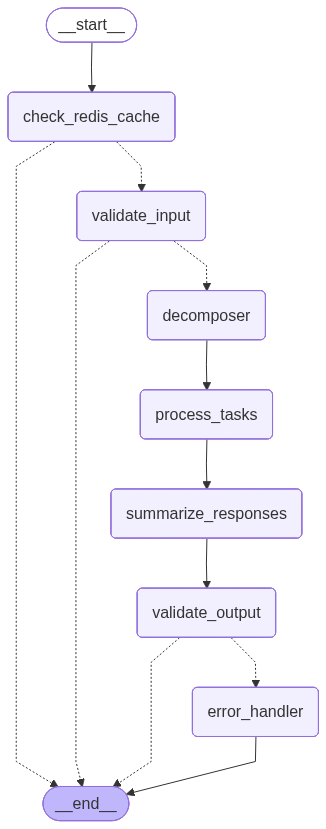

In [13]:
graph

# Text pipeline

In [14]:
user_info="Член профсоюзной организации: ППО Невинномысский Азот"
user_input=" Приветствую! Имеет ли право работодатель вызывать меня в выходной день из-за остановки цеха?"

In [15]:
input_text_embeding = text_embeder(user_info + user_input)

In [16]:
start_state = AgentState(
    user_id="141",
    user_info=user_info,
    user_input=user_input,
    embedding_input=input_text_embeding[0]
)

In [17]:
result = await graph.ainvoke(start_state)

In [18]:
result

{'embedding_input': array([ 2.02026367e-02,  7.04193115e-03, -5.69458008e-02, -1.97143555e-02,
        -1.35955811e-02, -4.84008789e-02,  5.06591797e-02, -2.23541260e-02,
         5.46264648e-02, -3.96118164e-02,  4.40979004e-02, -8.62426758e-02,
        -4.59594727e-02,  1.22375488e-02,  3.50646973e-02,  9.94110107e-03,
         7.02514648e-02, -5.02624512e-02, -7.77587891e-02,  8.31484795e-05,
        -4.18090820e-02,  9.60693359e-02,  8.94775391e-02, -7.08007812e-02,
        -8.47167969e-02, -2.04162598e-02,  5.19714355e-02, -4.68444824e-02,
         5.81359863e-02, -7.89794922e-02,  1.14501953e-01,  6.51245117e-02,
        -4.47692871e-02, -9.44824219e-02,  2.85339355e-02, -2.45971680e-02,
        -2.62603760e-02, -4.21447754e-02,  1.57318115e-02, -2.24609375e-02,
        -1.09985352e-01, -7.20214844e-02, -3.79333496e-02, -5.02395630e-03,
         6.24084473e-02, -8.03375244e-03, -7.23876953e-02, -2.51312256e-02,
         8.33129883e-02,  5.15747070e-02,  8.13598633e-02,  3.3264160

In [19]:
len(result["tasks"])

3

In [20]:
result["tasks"]

['Имеет ли работодатель право вызывать сотрудника в выходной день из‑за остановки цеха?',
 'Какие компенсации или надбавки полагаются, если сотрудник согласился выйти в выходной?',
 'Какой порядок оформления и какие документы требуются для вызова работника в выходной день?']

In [21]:
print(result["model_output"])

Да, работодатель может попросить вас выйти в выходной, но только если оформит это официальным приказом и заплатит за работу двойную ставку. Сначала попросите у руководства письменный приказ — это документ, без которого вызов считается незаконным. Проверьте, чтобы в расчётный лист была отдельная строка с двойной оплатой за выходной день. Если приказа нет или оплата не будет двойной, сообщите об этом в ваш профком и попросите оформить всё правильно. При необходимости напишите объяснительную, где укажете, что работу в выходной вы согласны выполнять только при условии двойной оплаты. Если возникнут споры, профком поможет отстоять ваши права.


## Проверяем простой текст

In [22]:
user_input="Привет!"

In [23]:
input_text_embeding = text_embeder(user_info + user_input)

In [24]:
start_state = AgentState(
    user_id="141",
    user_info=user_info,
    user_input=user_input,
    embedding_input=input_text_embeding[0]
)

In [25]:
result = await graph.ainvoke(start_state)

In [26]:
print(result["model_output"])

Здравствуйте! Я готов помочь вам, как члену ППО «Невинномысский Азот». Если вам нужна информация о правах, льготах или решении конкретной проблемы – просто скажите, что именно интересует. Мы можем быстро оформить заявление, подготовить объяснительную или подсказать, к кому обратиться в профком. Напишите, в чём нужна помощь, и я подскажу, что сделать прямо сейчас.


In [27]:
result["tasks"]

['Привет! Чем могу помочь?']